In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
n = 200

# Normal data + injected outliers
salary     = np.concatenate([np.random.normal(60000, 10000, n), [150000, 200000, 5000, 2000]])
age        = np.concatenate([np.random.normal(35, 8, n), [85, 90, -5, 120]])
experience = np.concatenate([np.random.normal(8, 3, n), [50, 60, -10, 45]])
score      = np.concatenate([np.random.normal(70, 10, n), [200, 250, -50, -30]])

df = pd.DataFrame({
    'Salary':     salary,
    'Age':        age,
    'Experience': experience,
    'Score':      score
})

print("Shape:", df.shape)
print("\nDescribe:\n", df.describe().round(2))

Shape: (204, 4)

Describe:
           Salary     Age  Experience   Score
count     204.00  204.00      204.00  204.00
mean    60173.81   36.41        8.30   70.53
std     15906.87   11.41        6.25   21.56
min      2000.00   -5.00      -10.00  -50.00
25%     52842.75   30.15        5.62   62.84
50%     59958.08   35.72        7.81   70.22
75%     65154.36   41.00        9.76   76.97
max    200000.00  120.00       60.00  250.00


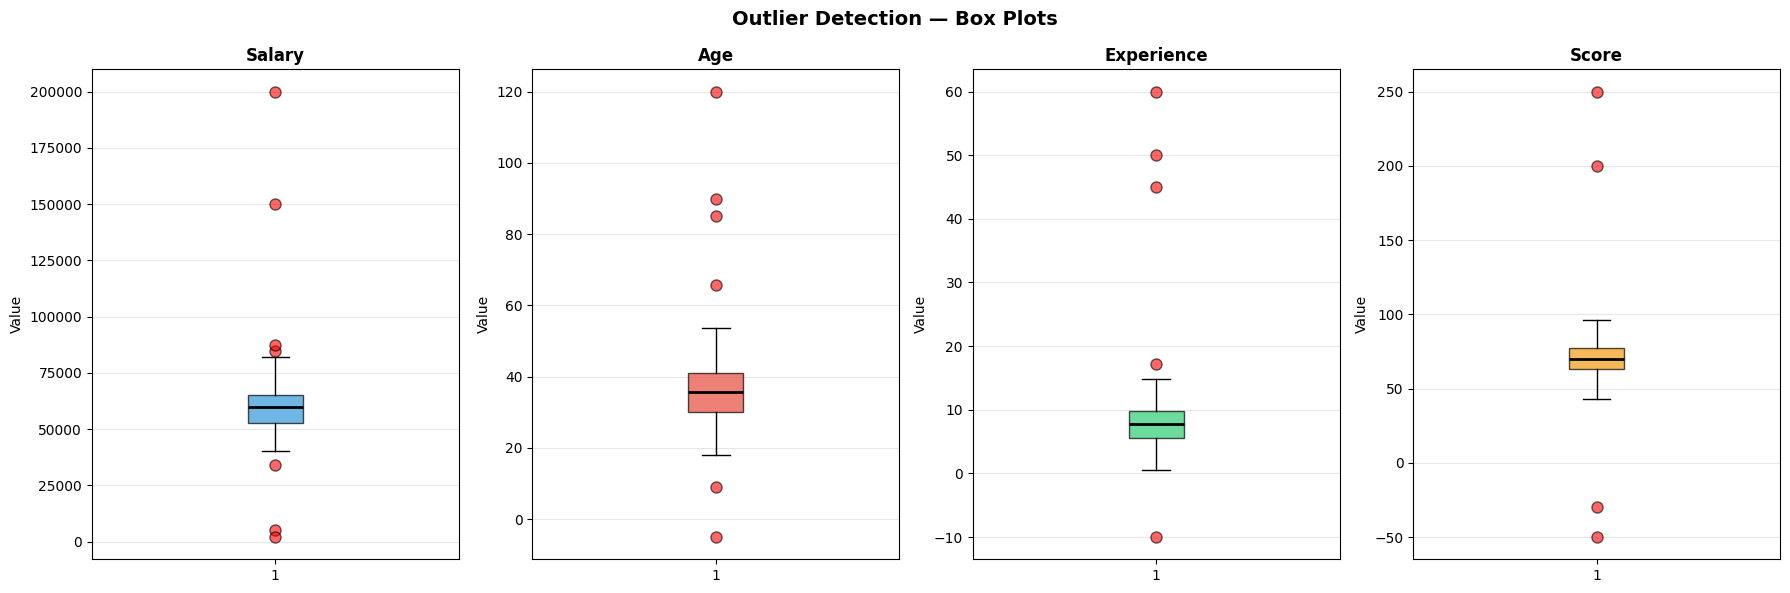

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('Outlier Detection — Box Plots', fontsize=14, fontweight='bold')

cols   = ['Salary', 'Age', 'Experience', 'Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[i].boxplot(df[col].dropna(),
                    patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='red',
                                    markersize=8, alpha=0.6))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
def detect_outliers_iqr(data, col):
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers    = data[(data[col] < lower) | (data[col] > upper)]
    clean       = data[(data[col] >= lower) & (data[col] <= upper)]

    print(f"\n{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Lower bound: {lower:.2f}")
    print(f"  Upper bound: {upper:.2f}")
    print(f"  Outliers found: {len(outliers)}")
    print(f"  Outlier values: {sorted(outliers[col].values)}")

    return outliers, clean, lower, upper

print("=== IQR Outlier Detection ===")
for col in ['Salary', 'Age', 'Experience', 'Score']:
    detect_outliers_iqr(df, col)

=== IQR Outlier Detection ===

Salary:
  Q1=52842.75, Q3=65154.36, IQR=12311.61
  Lower bound: 34375.35
  Upper bound: 83621.77
  Outliers found: 7
  Outlier values: [np.float64(2000.0), np.float64(5000.0), np.float64(33802.548959102554), np.float64(84632.42112485286), np.float64(87201.69166589619), np.float64(150000.0), np.float64(200000.0)]

Age:
  Q1=30.15, Q3=41.00, IQR=10.85
  Lower bound: 13.88
  Upper bound: 57.27
  Outliers found: 6
  Outlier values: [np.float64(-5.0), np.float64(9.06986127944742), np.float64(65.82185192523777), np.float64(85.0), np.float64(90.0), np.float64(120.0)]

Experience:
  Q1=5.62, Q3=9.76, IQR=4.14
  Lower bound: -0.59
  Upper bound: 15.97
  Outliers found: 5
  Outlier values: [np.float64(-10.0), np.float64(17.236642425365712), np.float64(45.0), np.float64(50.0), np.float64(60.0)]

Score:
  Q1=62.84, Q3=76.97, IQR=14.13
  Lower bound: 41.64
  Upper bound: 98.17
  Outliers found: 4
  Outlier values: [np.float64(-50.0), np.float64(-30.0), np.float64(200.

In [4]:
def detect_outliers_zscore(data, col, threshold=3):
    z_scores = np.abs(stats.zscore(data[col].dropna()))
    outlier_mask = z_scores > threshold

    outliers = data[col].dropna()[outlier_mask]
    clean    = data[col].dropna()[~outlier_mask]

    print(f"\n{col}:")
    print(f"  Mean={data[col].mean():.2f}, Std={data[col].std():.2f}")
    print(f"  Threshold: |z| > {threshold}")
    print(f"  Outliers found: {outlier_mask.sum()}")
    print(f"  Outlier values: {sorted(outliers.values)}")

    return outliers, clean

print("=== Z-Score Outlier Detection (threshold=3) ===")
for col in ['Salary', 'Age', 'Experience', 'Score']:
    detect_outliers_zscore(df, col)

# IQR vs Z-score comparison
print("""
IQR Method:
  - Does not assume normal distribution
  - Better for skewed data
  - Uses 1.5 * IQR rule (Tukey's method)
  - More robust to extreme outliers

Z-Score Method:
  - Assumes normal distribution
  - Threshold typically 2 or 3 std devs
  - Sensitive to extreme outliers (they inflate std dev)
  - Better for symmetric, normally distributed data
""")

=== Z-Score Outlier Detection (threshold=3) ===

Salary:
  Mean=60173.81, Std=15906.87
  Threshold: |z| > 3
  Outliers found: 4
  Outlier values: [np.float64(2000.0), np.float64(5000.0), np.float64(150000.0), np.float64(200000.0)]

Age:
  Mean=36.41, Std=11.41
  Threshold: |z| > 3
  Outliers found: 4
  Outlier values: [np.float64(-5.0), np.float64(85.0), np.float64(90.0), np.float64(120.0)]

Experience:
  Mean=8.30, Std=6.25
  Threshold: |z| > 3
  Outliers found: 3
  Outlier values: [np.float64(45.0), np.float64(50.0), np.float64(60.0)]

Score:
  Mean=70.53, Std=21.56
  Threshold: |z| > 3
  Outliers found: 4
  Outlier values: [np.float64(-50.0), np.float64(-30.0), np.float64(200.0), np.float64(250.0)]

IQR Method:
  - Does not assume normal distribution
  - Better for skewed data
  - Uses 1.5 * IQR rule (Tukey's method)
  - More robust to extreme outliers

Z-Score Method:
  - Assumes normal distribution
  - Threshold typically 2 or 3 std devs
  - Sensitive to extreme outliers (they inf


Salary:
  Q1=52842.75, Q3=65154.36, IQR=12311.61
  Lower bound: 34375.35
  Upper bound: 83621.77
  Outliers found: 7
  Outlier values: [np.float64(2000.0), np.float64(5000.0), np.float64(33802.548959102554), np.float64(84632.42112485286), np.float64(87201.69166589619), np.float64(150000.0), np.float64(200000.0)]

Strategy 1 — Remove:
  Before: 204 rows | After: 197 rows

Strategy 2 — Cap (Winsorization):
  Max before: 200000 | Max after: 83622
  Min before: 2000 | Min after: 34375

Strategy 3 — Log Transform:
  Original range: 2000 – 200000
  Log range:      7.60 – 12.21


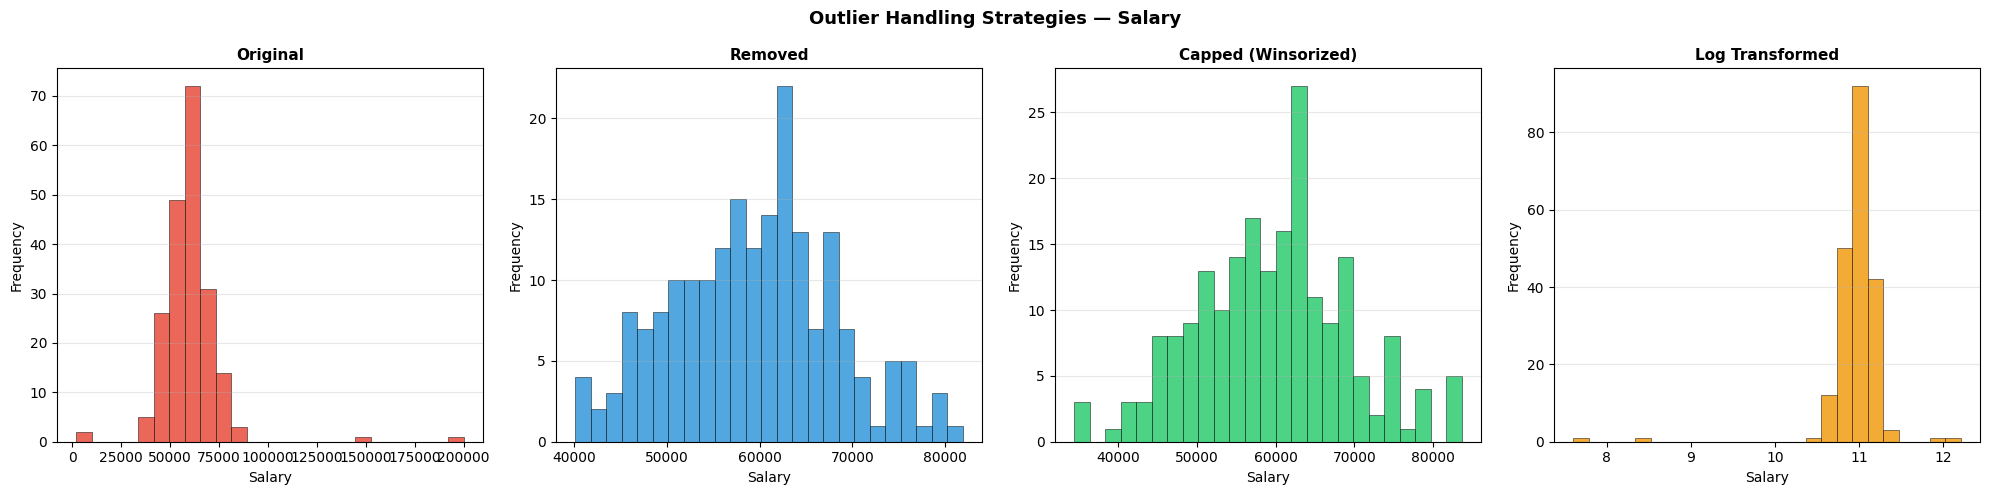

In [5]:
col = 'Salary'

_, _, lower, upper = detect_outliers_iqr(df, col)

# Strategy 1: Remove outliers
df_removed = df[(df[col] >= lower) & (df[col] <= upper)].copy()
print(f"\nStrategy 1 — Remove:")
print(f"  Before: {len(df)} rows | After: {len(df_removed)} rows")

# Strategy 2: Cap (Winsorization) — clip to bounds
df_capped = df.copy()
df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
print(f"\nStrategy 2 — Cap (Winsorization):")
print(f"  Max before: {df[col].max():.0f} | Max after: {df_capped[col].max():.0f}")
print(f"  Min before: {df[col].min():.0f} | Min after: {df_capped[col].min():.0f}")

# Strategy 3: Log transformation — compresses large values
df_log = df.copy()
df_log[col] = np.log1p(df_log[col].clip(lower=1))  # log1p handles 0 safely
print(f"\nStrategy 3 — Log Transform:")
print(f"  Original range: {df[col].min():.0f} – {df[col].max():.0f}")
print(f"  Log range:      {df_log[col].min():.2f} – {df_log[col].max():.2f}")

# Visualize all 3 strategies
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Outlier Handling Strategies — Salary', fontsize=13, fontweight='bold')

data_list   = [df[col], df_removed[col], df_capped[col], df_log[col]]
titles      = ['Original', 'Removed', 'Capped (Winsorized)', 'Log Transformed']
plot_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, (data, title, color) in enumerate(zip(data_list, titles, plot_colors)):
    axes[i].hist(data, bins=25, color=color, edgecolor='black',
                 linewidth=0.4, alpha=0.85)
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Salary')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outlier_strategies.png', dpi=150, bbox_inches='tight')
plt.show()


duration_int:
  Q1=87.00, Q3=114.00, IQR=27.00
  Lower bound: 46.50
  Upper bound: 154.50
  Outliers found: 450
  Outlier values: [np.float64(3.0), np.float64(5.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(11.0), np.float64(12.0), np.float64(12.0), np.float64(12.0), np.float64(13.0), np.float64(13.0), np.float64(13.0), np.float64(14.0), np.float64(14.0), np.float64(14.0), np.float64(15.0), np.float64(15.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(17.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(19.0), np.float64(20.0), np.float64(20.0), np.float64(21.0), np.float64(21.0), np.float64(21.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(22.0), np.float64(23.0), np.float

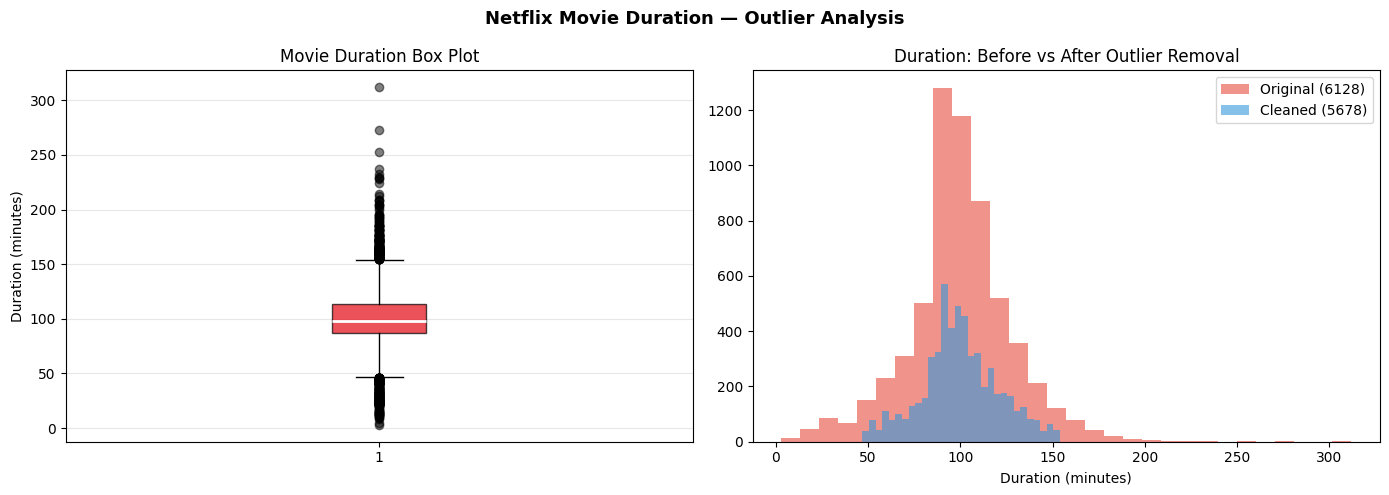


Outlier movies (duration < 46 or > 154 min):
                            title  duration_int
4253   Black Mirror: Bandersnatch         312.0
717   Headspace: Unwind Your Mind         273.0
2491       The School of Mischief         253.0
2487               No Longer kids         237.0
2484           Lock Your Girls In         233.0
2488              Raya and Sakina         230.0
166   Once Upon a Time in America         229.0
7932                       Sangam         228.0
1019                       Lagaan         224.0
4573                 Jodhaa Akbar         214.0


In [7]:
df_netflix = pd.read_csv('netflix_titles.csv')
df_netflix['duration_int'] = df_netflix['duration'].str.extract(r'(\d+)').astype(float)
movies = df_netflix[df_netflix['type'] == 'Movie'].dropna(subset=['duration_int'])

# IQR on movie duration
_, _, lower, upper = detect_outliers_iqr(movies, 'duration_int')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Netflix Movie Duration — Outlier Analysis', fontsize=13, fontweight='bold')

# Box plot
axes[0].boxplot(movies['duration_int'],
                patch_artist=True,
                boxprops=dict(facecolor='#e50914', alpha=0.7),
                medianprops=dict(color='white', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='black',
                                markersize=6, alpha=0.5))
axes[0].set_title('Movie Duration Box Plot')
axes[0].set_ylabel('Duration (minutes)')
axes[0].grid(True, alpha=0.3, axis='y')

# Before vs after removing outliers
movies_clean = movies[(movies['duration_int'] >= lower) &
                       (movies['duration_int'] <= upper)]
axes[1].hist(movies['duration_int'], bins=30, alpha=0.6,
             color='#e74c3c', label=f'Original ({len(movies)})')
axes[1].hist(movies_clean['duration_int'], bins=30, alpha=0.6,
             color='#3498db', label=f'Cleaned ({len(movies_clean)})')
axes[1].set_title('Duration: Before vs After Outlier Removal')
axes[1].set_xlabel('Duration (minutes)')
axes[1].legend()

plt.tight_layout()
plt.savefig('netflix_duration_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOutlier movies (duration < {lower:.0f} or > {upper:.0f} min):")
print(movies[
    (movies['duration_int'] < lower) | (movies['duration_int'] > upper)
][['title', 'duration_int']].sort_values('duration_int', ascending=False).head(10))